In [1]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Subset
import wandb

In [2]:
# ==================== 本次改动说明 ====================
# baseline（见 CIFAR10-baseline.ipynb）是官方教程原版：batch_size=4、只训练 2 轮、
# 模型只有 6/16 个卷积通道，测试集准确率 48.00%。
# 分数低不是因为模型笨，而是四个问题叠在一起：
#   1) 只训练 2 轮，模型还没学够就停了；
#   2) batch_size=4 太小，BatchNorm 的批次统计量抖得厉害，显卡也喂不满；
#   3) 完全没有数据增强，5 万张训练图被反复"背"下来，泛化能力差；
#   4) 归一化用的是教程占位值 0.5/0.5/0.5，不是 CIFAR-10 的真实统计量。
#
# 本次改动清单（按 数据 -> 模型 -> 训练 的顺序）：
#   1) batch_size 4 -> 128，并开启 pin_memory
#   2) 归一化换成 CIFAR-10 的真实均值/标准差
#   3) 训练集加随机裁剪 + 随机水平翻转（验证集/测试集不做增强）
#   4) 从训练集划出 10% 当验证集，用它挑出最好的一轮
#   5) 模型换成 VGG 风格小网络：64/128/256 通道，全部 3x3 卷积 + BN
#   6) 损失函数加标签平滑，优化器加权重衰减，学习率余弦退火
#   7) 训练轮数 2 -> 40
# =====================================================

config = {
    "learning_rate": 0.001,
    "batch_size": 128,
    "epochs": 40,               # 改动：2 -> 40，CIFAR-10 比 MNIST 系列难，需要更多轮
    "optimizer": "Adam",
    "weight_decay": 5e-4,       # 改动：权重衰减，防止权重长得太大
    "label_smoothing": 0.1,     # 改动：标签平滑
    "val_ratio": 0.1,           # 改动：从训练集里划 10% 当验证集
    "seed": 42,                 # 固定随机种子，让结果可复现
    "model": "VGG_small_3x3_BN_CIFAR10",
}

wandb.init(
    project="cifar10-cnn",      # 项目名，在 W&B 网站上会看到这个项目
    name="vgg-aug-cosine",      # 本次实验名，和 baseline 区分开
    config=config               # 把上面的超参数全部记录下来
)

# 固定随机种子：权重初始化、数据打乱顺序、验证集划分都固定下来，换台机器也能复现
torch.manual_seed(config["seed"])

# ---------- 1. 准备数据 ----------
# 训练集和验证集/测试集要用两套不同的预处理。
#
# 训练集做"数据增强"（Data Augmentation，就是人为给图片造一点小变化）：
#   RandomCrop(32, padding=4)：先在图片四周补 4 圈，变成 40x40，再随机裁回 32x32。
#                              效果约等于把物体随机平移几个像素，模型就不会死记
#                              "飞机必须出现在正中间"这种无用的位置信息。
#   RandomHorizontalFlip()：随机左右翻转。猫朝左朝右都是猫，标签不变。
# 注意这两个操作都要放在 ToTensor() 之前，因为它们处理的是图片（PIL 格式）。
#
# 验证集和测试集只做"归一化"，不做增强：评估的标准要每一轮都一样，才好比较。
CIFAR_MEAN = (0.4914, 0.4822, 0.4465)   # CIFAR-10 训练集的真实像素均值（改动）
CIFAR_STD = (0.2470, 0.2435, 0.2616)    # CIFAR-10 训练集的真实像素标准差（改动）

val_transform = transforms.Compose([
    transforms.ToTensor(),                  # 像素 0-255 -> 0-1 的张量
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),   # 再标准化，让数据分布稳定
])

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),   # 改动：随机裁剪
    transforms.RandomHorizontalFlip(),      # 改动：随机水平翻转
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# 同一份训练数据加载两遍：
# 一份挂"带增强"的 transform 用来训练，一份挂"不增强"的 transform 用来当验证集。
# 这样验证集的评估标准才是稳定的。
train_full = torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_transform, download=True)
val_full = torchvision.datasets.CIFAR10(root='./data', train=True, transform=val_transform, download=True)
test_set = torchvision.datasets.CIFAR10(root='./data', train=False, transform=val_transform, download=True)

# 用固定的随机种子打乱下标，前 10% 当验证集，剩下的当训练集。
generator = torch.Generator().manual_seed(config["seed"])
perm = torch.randperm(len(train_full), generator=generator).tolist()
val_size = int(len(train_full) * config["val_ratio"])
train_set = Subset(train_full, perm[val_size:])
val_set = Subset(val_full, perm[:val_size])

# DataLoader：按批喂数据。
# pin_memory=True 让数据预先放进"锁页内存"，搬到显卡上更快（改动）。
# num_workers=0 是 Windows 上的稳妥选择，想加速可以改成 2 试试。
train_loader = DataLoader(train_set, batch_size=config["batch_size"], shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_set, batch_size=config["batch_size"], shuffle=False,
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_set, batch_size=config["batch_size"], shuffle=False,
                         num_workers=0, pin_memory=True)

print(f"训练集 {len(train_set)} 张，验证集 {len(val_set)} 张，测试集 {len(test_set)} 张")

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from C:\Users\35314\_netrc.
wandb: Currently logged in as: 3531427435 (3531427435-none) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: setting up run rlxtbzxu
wandb: Tracking run with wandb version 0.30.0
wandb: Run data is saved locally in E:\code\PycharmProjects\pythonProject\pytorch\wandb\run-20260912_143455-rlxtbzxu
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run vgg-aug-cosine
wandb:  View project at https://wandb.ai/3531427435-none/cifar10-cnn
wandb:  View run at https://wandb.ai/3531427435-none/cifar10-cnn/runs/rlxtbzxu


训练集 45000 张，验证集 5000 张，测试集 10000 张


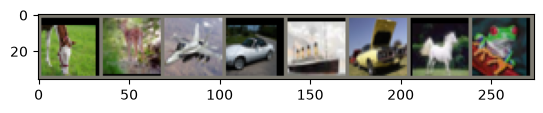

horse deer  plane car   ship  car   horse frog 


In [3]:
# ---------- 2. 先看几张训练图，确认数据没问题 ----------
# CIFAR-10 的 10 个类别，标签 0-9 和名字一一对应
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

# 反归一化要用到同一组均值/标准差，这里写成 3x1x1 的形状，方便直接和 (3,H,W) 的图片相乘
mean_tensor = torch.tensor(CIFAR_MEAN).view(3, 1, 1)
std_tensor = torch.tensor(CIFAR_STD).view(3, 1, 1)


def imshow(img):
    '''把归一化后的张量还原成能看的图片再画出来。
    归一化时做的是 (x - mean) / std，所以显示时要反着来：x * std + mean。
    注意：教程原版这里写的是 img * 2 + 0.5，那是按 0.5/0.5 的归一化反推的，
    而且系数还写错了（应该是 * 0.5 + 0.5），所以 matplotlib 才会报
    "Clipping input data" 的越界警告。现在换成真实的均值/标准差就正常了。'''
    img = img * std_tensor + mean_tensor
    img = torch.clamp(img, 0, 1)        # 保险起见，裁到 [0,1] 区间内
    npimg = img.numpy()
    plt.imshow(npimg.transpose((1, 2, 0)))   # (3,H,W) -> (H,W,3)，matplotlib 要的格式
    plt.show()


dataiter = iter(train_loader)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images[:8]))    # 画前 8 张（都是做过增强的）
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(8)))

In [4]:
# ---------- 3. 定义模型 ----------

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("使用设备:", device)


class Net(nn.Module):
    '''VGG 风格的小网络，全部用 3x3 卷积。

    为什么从 5x5 换成 3x3：两层 3x3 卷积叠起来，能"看到"的区域和一层 5x5 差不多大，
    但参数更少，中间还能多插一次 ReLU（非线性），表达力反而更强 —— 这是 VGG 的核心思路。
    32x32 的输入经过 3 次池化下采样，最后变成 4x4。
    '''

    def __init__(self, num_classes=10):
        super().__init__()

        def conv_block(in_channels, out_channels):
            '''一个卷积块：两层"卷积 + BN + ReLU"，再池化一次把长宽减半。'''
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(2),        # 长宽各减半
            )

        # 通道数逐层翻倍：32x32 -> 16x16 -> 8x8 -> 4x4
        self.block1 = conv_block(3, 64)
        self.block2 = conv_block(64, 128)
        self.block3 = conv_block(128, 256)

        # 分类头：把 256x4x4 的特征图摊平成 4096 维，再映射到 10 个类别
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 4 * 4, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),        # 训练时随机"关掉"一半神经元，防止过拟合
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.block1(x)          # 卷积块 1
        x = self.block2(x)          # 卷积块 2
        x = self.block3(x)          # 卷积块 3
        x = self.classifier(x)      # 分类头
        return x


net = Net().to(device)              # 把模型搬到显卡上
print(net)
print("参数量:", sum(p.numel() for p in net.parameters()))

# 让 W&B 定期记录参数的直方图、梯度分布。log_freq=500 表示每 500 个 batch 记一次，
# 这个网络每轮约 350 个 batch，也就是大约每轮记一次。这个值调小会明显拖慢训练。
wandb.watch(net, log="all", log_freq=500)

使用设备: cuda
Net(
  (block1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=Fal

In [5]:
# ---------- 4. 损失函数、优化器、学习率调度 ----------
# label_smoothing=0.1（标签平滑）：不再要求模型给正确类别打满 100 分，
# 而是"打到 90 分就算对"。这样模型不会变得过度自信，是一个常见的小幅涨点手段。
criterion = nn.CrossEntropyLoss(label_smoothing=config["label_smoothing"])

# weight_decay（权重衰减）：给权重加一点"别长太大"的约束，
# 和 Dropout 一样都是防过拟合的手段。
optimizer = optim.Adam(
    net.parameters(),
    lr=config["learning_rate"],
    weight_decay=config["weight_decay"],
)

# 余弦退火（学习率调度）：学习率从 1e-3 沿着余弦曲线平滑降到接近 0。
# 前期步子大、学得快；后期步子小，能稳稳落在一个好位置，
# 比一直用固定学习率更容易在训练后期继续涨点。
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=config["epochs"])

In [6]:
# ---------- 5. 评估函数 + 训练循环 ----------


def evaluate(model, loader):
    '''算模型在某个数据集上的准确率(%)。
    评估时必须先 model.eval()：让 BatchNorm 用固定的统计量、把 Dropout 关掉。
    评估不需要梯度，所以用 torch.no_grad() 包起来，省显存也更快。'''
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


# 训练循环（铁打的五步舞曲：清梯度 -> 前向 -> 算损失 -> 反向 -> 更新参数）
num_epochs = config["epochs"]
best_val_acc = 0.0      # 记录验证集上最好的准确率
best_state = None       # 记下最好那一轮的权重

for epoch in range(num_epochs):
    net.train()         # 确保训练时 BatchNorm 更新统计量、Dropout 生效
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = net(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    # 每轮结束后算一次验证集准确率，用它来判断模型是不是在变好
    val_acc = evaluate(net, val_loader)

    # 每轮结束后把学习率往下调一档
    scheduler.step()
    current_lr = optimizer.param_groups[0]["lr"]

    # 只保留验证集上最好的那一轮权重，避免"最后一轮反而变差"
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(net.state_dict())

    print(
        f"Epoch [{epoch+1}/{num_epochs}], "
        f"Loss: {avg_loss:.4f}, "
        f"Val Acc: {val_acc:.2f}%, "
        f"Best Val: {best_val_acc:.2f}%, "
        f"LR: {current_lr:.6f}"
    )

    # 记录到 W&B：训练损失、验证准确率、学习率的变化
    wandb.log({
        "epoch": epoch + 1,
        "train/loss": avg_loss,
        "val/accuracy": val_acc,
        "learning_rate": current_lr,
    })

print("Finished Training")

Epoch [1/40], Loss: 1.5513, Val Acc: 67.18%, Best Val: 67.18%, LR: 0.000998
Epoch [2/40], Loss: 1.2064, Val Acc: 70.50%, Best Val: 70.50%, LR: 0.000994
Epoch [3/40], Loss: 1.0952, Val Acc: 75.08%, Best Val: 75.08%, LR: 0.000986
Epoch [4/40], Loss: 1.0353, Val Acc: 77.62%, Best Val: 77.62%, LR: 0.000976
Epoch [5/40], Loss: 0.9882, Val Acc: 81.16%, Best Val: 81.16%, LR: 0.000962
Epoch [6/40], Loss: 0.9510, Val Acc: 81.20%, Best Val: 81.20%, LR: 0.000946
Epoch [7/40], Loss: 0.9202, Val Acc: 79.40%, Best Val: 81.20%, LR: 0.000926
Epoch [8/40], Loss: 0.8987, Val Acc: 81.38%, Best Val: 81.38%, LR: 0.000905
Epoch [9/40], Loss: 0.8724, Val Acc: 82.92%, Best Val: 82.92%, LR: 0.000880
Epoch [10/40], Loss: 0.8497, Val Acc: 83.62%, Best Val: 83.62%, LR: 0.000854
Epoch [11/40], Loss: 0.8328, Val Acc: 84.94%, Best Val: 84.94%, LR: 0.000825
Epoch [12/40], Loss: 0.8123, Val Acc: 86.04%, Best Val: 86.04%, LR: 0.000794
Epoch [13/40], Loss: 0.8010, Val Acc: 81.72%, Best Val: 86.04%, LR: 0.000761
Epoch [1

In [7]:
# ---------- 6. 用验证集挑出的最好权重，跑一次测试集 ----------
# 测试集只在最后用一次：调参过程看验证集，最后的成绩看测试集，两者不能混用。
net.load_state_dict(best_state)
test_acc = evaluate(net, test_loader)
print(f"验证集最佳准确率: {best_val_acc:.2f}%")
print(f"测试集准确率: {test_acc:.2f}%")

# ---------- 7. 每个类别的准确率 ----------
# 只看总分不够：CIFAR-10 里猫和狗、鹿和马长得像，弄清模型具体在哪几类上栽跟头，
# 比一个孤零零的总分更有说服力。
class_correct = [0] * 10
class_total = [0] * 10

net.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = net(images)
        _, predicted = torch.max(outputs, 1)
        for label, pred in zip(labels, predicted):
            label = label.item()
            class_total[label] += 1
            if label == pred.item():
                class_correct[label] += 1

per_class_acc = {}
for i in range(10):
    acc = 100 * class_correct[i] / class_total[i]
    per_class_acc[classes[i]] = acc
    print(f"{classes[i]:5s} 准确率: {acc:.2f}%  (共 {class_total[i]} 张)")

# 把每类准确率做成柱状图记到 W&B（wandb.Table 是一张二维表）
per_class_table = wandb.Table(
    data=[[name, per_class_acc[name]] for name in classes],
    columns=["class", "accuracy"],
)

wandb.log({
    "best_val/accuracy": best_val_acc,
    "test/accuracy": test_acc,
    "test/per_class_accuracy": wandb.plot.bar(
        per_class_table, "class", "accuracy", title="CIFAR-10 各类别准确率"
    ),
})

# ---------- 8. 保存模型并上传 W&B Artifact ----------
# 保存的是验证集上表现最好的那份权重，而不是训练最后一轮的权重
torch.save(best_state, "cifar10_cnn.pth")
artifact = wandb.Artifact(
    name="cifar10-cnn",
    type="model"
)
artifact.add_file("cifar10_cnn.pth")
wandb.log_artifact(artifact)
wandb.finish()

验证集最佳准确率: 92.30%
测试集准确率: 91.91%
plane 准确率: 92.70%  (共 1000 张)
car   准确率: 96.60%  (共 1000 张)
bird  准确率: 87.80%  (共 1000 张)
cat   准确率: 82.70%  (共 1000 张)
deer  准确率: 93.80%  (共 1000 张)
dog   准确率: 89.70%  (共 1000 张)
frog  准确率: 94.00%  (共 1000 张)
horse 准确率: 92.40%  (共 1000 张)
ship  准确率: 94.40%  (共 1000 张)
truck 准确率: 95.00%  (共 1000 张)


wandb: updating run metadata; uploading artifact run-rlxtbzxu-testper_class_accuracy_table-oCrxgw; uploading artifact cifar10-cnn
wandb: uploading artifact run-rlxtbzxu-testper_class_accuracy_table-oCrxgw; uploading artifact cifar10-cnn
wandb: uploading artifact cifar10-cnn
wandb: uploading artifact cifar10-cnn; uploading media\table\test\per_class_accuracy_table_40_014e982470a31ac515d6.table.json; uploading wandb-summary.json; uploading config.yaml
wandb: uploading artifact cifar10-cnn; uploading wandb-summary.json
wandb: uploading artifact cifar10-cnn
wandb: uploading history steps 40-40, summary
wandb: 
wandb: Run history:
wandb: best_val/accuracy ▁
wandb:             epoch ▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
wandb:     learning_rate ██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
wandb:     test/accuracy ▁
wandb:        train/loss █▆▅▄▄▄▄▃▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb:      val/accuracy ▁▂▃▄▅▅▄▅▅▆▆▆▅▆▆▆▇▆▇▇▇▇▇▇▇██▇████████████
wandb: 
wandb: Run summary:
wandb: best_val/accu

In [ ]:
# ---------- 8. 用保存好的模型复算三个准确率（可单独运行，不需要重新训练） ----------
# 这一格的作用是把「训练集 / 验证集 / 测试集」三个准确率放在一起看，判断瓶颈在哪：
#   训练集很高、测试集明显低 -> 过拟合：模型有能力"背下"训练集，但泛化不够，
#                               想再涨分要靠更强的数据增强或正则化，甚至换架构；
#   两个都很低               -> 欠拟合：模型容量不够，该把网络做大或多训几轮。
#
# 想单独运行这一格，只需要内核里先跑过三个"便宜"的单元：
#   cell 0（导入库）、cell 1（准备数据）、cell 3（定义模型）。
# 不用重跑那 40 轮训练，全程大约 1 分钟。
#
# 两个注意点：
#   1) 权重来自 cifar10_cnn.pth，也就是"验证集上最好的那一轮"；
#   2) 三个数据集都用"不增强"的预处理来评估。数据增强只属于训练过程，
#      评估时再增强会把准确率算虚。

net.load_state_dict(torch.load("cifar10_cnn.pth", weights_only=True))


def accuracy(model, loader):
    '''算准确率(%)。这里重新写一遍评估循环，是为了让这一格不依赖训练单元、单独就能跑。'''
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


# 训练时用的那 45000 张：val_full 挂的正是"不增强"的 transform，
# 再用和训练时完全一样的下标，切出训练集那部分。
train_eval_set = Subset(val_full, perm[val_size:])
train_eval_loader = DataLoader(train_eval_set, batch_size=config["batch_size"],
                               shuffle=False, num_workers=0, pin_memory=True)

train_acc = accuracy(net, train_eval_loader)
val_acc = accuracy(net, val_loader)
test_acc = accuracy(net, test_loader)

print(f"训练集准确率（{len(train_eval_set)} 张，无增强）: {train_acc:.2f}%")
print(f"验证集准确率（{len(val_set)} 张）: {val_acc:.2f}%")
print(f"测试集准确率（{len(test_set)} 张）: {test_acc:.2f}%")
print(f"训练集与测试集的差距: {train_acc - test_acc:.2f} 个百分点")
